# Imports

946dbf73-4fcd-45f5-baf7-656f31b3b0ff

In [3]:
import os

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, StandardScaler, PowerTransformer
from sklearn.metrics import roc_auc_score, average_precision_score


/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data loading

In [4]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


There are 166 features to the dataset, 92 local and 74 aggregated. [add source - demistifying... ]
The CSV does not have the columns defined
txid - transaction id
time_step - 1-49 timestamps groups
lf_{number} - local feature number 1-92
af_{number} - aggregated feature number 1-74


In [5]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [6]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [7]:
# map classes: licit - 0; illicit- 1;  unknown -2
class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True)


,txId,class
0,230425980,2
1,5530458,2
2,232022460,2
3,232438397,0
4,230460314,2
...,...,...
203764,173077460,2
203765,158577750,2
203766,158375402,1
203767,158654197,2


In [8]:
df = pd.merge(features, classes, on='txId')

## Graph Feature Enrichment

In [44]:
# feature enrichment - add edges
def add_graph_features(target_df, input_edges):                                           
      node_ids = set(target_df['txId'])                                                   

        # select only edgest in in- and out- ids                                                                                   
      relevant_edges = input_edges[                                                         
          input_edges['txId1'].isin(node_ids) &                                             
          input_edges['txId2'].isin(node_ids)                                               
      ]                                                                                     
                                                                                            
      G = nx.from_pandas_edgelist(relevant_edges, 'txId1', 'txId2',                         
                                   create_using=nx.DiGraph())                               
                                                                                            
      # directed degree                                                                     
      in_degree  = dict(G.in_degree())      # directed degree in                                                
      out_degree = dict(G.out_degree())                      # out                            
      clustering = nx.clustering(G.to_undirected())    # clustering coefficient                                       
      pagerank = nx.pagerank(G, alpha=0.85)   

      idx = target_df['txId']
      new_cols_df = target_df.assign(
            in_degree = idx.map(lambda x: in_degree.get(x, 0)),
            out_degree= idx.map(lambda x: out_degree.get(x, 0)),
            degree_ratio=  idx.map(lambda x: in_degree.get(x, 0) / (out_degree.get(x, 0) + 1e-9)),
            clustering_coef= idx.map(lambda x: clustering.get(x, 0)),
            pagerank= idx.map(lambda x: pagerank.get(x, 0)),
            )

                                                                                          
      return new_cols_df
#pd.concat([target_df, new_cols_df], axis=1) 


In [45]:
enriched_df = add_graph_features(df, edges)

In [46]:
enriched_df.shape

(203769, 173)

In [47]:
train_df = enriched_df[(enriched_df['class'] == 0) & (enriched_df['time_step'] <= 35)].copy()
test_df = enriched_df[enriched_df['time_step'] > 35].copy()


In [48]:
train_df.shape

(27591, 173)

In [13]:
#TODO: set embedding of node id

train on licit class 0
training set: time-step 1-30
val: 31-49

In [14]:
## TODO: add embeddings for the connecting transactions. 

In [15]:
# TODO compare minmax scaler to maxabs scaler - how to test which one is better fitting

In [49]:
# Identify feature columns (excluding metadata)
metadata_cols = ['txId', 'time_step', 'class']

X_train_raw = train_df.drop(columns=metadata_cols)
X_test_raw = test_df.drop(columns=metadata_cols)


# Helper Function - train and get results

In [50]:
def model_test_orchestrator(X_train, X_test, test_df, rank=16,  init='nndsvda'):
    

    nmf = NMF(n_components=rank, init=init, random_state=90, max_iter=500)
    W_train = nmf.fit_transform(X_train)
    H = nmf.components_     # The "Licit Patterns" matrix
    W_test = nmf.transform(X_test)

    X_test_recon = np.dot(W_test, H)

    # measure the error
    errors = np.mean((X_test - X_test_recon)**2, axis=1)
    
    test_results = pd.DataFrame({
        'txId': test_df['txId'].values,
        'time_step': test_df['time_step'].values,
        'class': test_df['class'].values,
        'anomaly_score': errors
    })
    
    # normalize error: 
    test_results['norm_error'] = MinMaxScaler().fit_transform(test_results[['anomaly_score']]).flatten()
    test_results[test_results['class'] == 0].groupby('time_step')['anomaly_score'].mean().plot()
    
    return nmf, H, W_test, test_results



In [51]:
def conf_matrix_maker(test_results, th=0.1):
    preds = test_results[test_results['class'] < 2].copy()

    tp = test_results[(test_results['class']==1) & (np.abs(test_results['norm_error']) > th)]    # 2
    tn = test_results[(test_results['class']==0) & (np.abs(test_results['norm_error']) < th)]    # 28,920
    fp = test_results[(test_results['class']==0) & (np.abs(test_results['norm_error']) > th)]    # 1155
    fn = test_results[(test_results['class']==1) & (np.abs(test_results['norm_error']) < th)]    # 4019

    # If the model says "fraud," is it actually fraud? - having few false alarm - high precision reduces fp. 
    try: 
        precision = tp.shape[0] / (tp.shape[0] + fp.shape[0])
    except ZeroDivisionError: 
        precision = 0
    # Did the model catch all the fraud, or did some slip through - how many actual positive were predicted as positives
    try:    
        recall = tp.shape[0] / (fn.shape[0] + tp.shape[0])
    except ZeroDivisionError: 
        recall = 0
    print(f'tp: {tp.shape[0]}, fp: {fp.shape[0]}, tn: {tn.shape[0]}, fn: {fn.shape[0]}')
    return precision, recall

# Collaborative Filtering with NMF 

justification: treating the fraud detection as anomaly detection, CF might be able to uncover latent features in the bitcoin transactions structure, and so deal better with high bias and sparse data that affect classification. 
the theory - fraud could be detected with high reconstruction errors. 
NMF is an explainable model that adds reconstructed features as additive parts to compose the full picture, which has high value in the finance industry. 
Challenge - the values are not nn. 

## Test1: MaxAbsScaler

In [52]:
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# add +1 to avoid negative values
X_train_abs = X_train_scaled + 1.0
X_test_abs = X_test_scaled + 1.0

addition of 1 is done to avoid unseen negatives in the test data. therefore the entire dataset is arbitrarily shifted by 1. 



In [53]:
rows, cols = np.where(X_test_abs < 0)
print(list(zip(rows, cols)))

[(np.int64(7461), np.int64(99)), (np.int64(13336), np.int64(99)), (np.int64(13336), np.int64(100)), (np.int64(13336), np.int64(102)), (np.int64(14209), np.int64(100)), (np.int64(14335), np.int64(100)), (np.int64(17845), np.int64(100)), (np.int64(46387), np.int64(100)), (np.int64(50485), np.int64(100))]


in this case, also after the shifitng, additional 22 values are still negative. they were 
there are 22 negative values, stamming from columns 100, 102 and 99 - all aggregative. 

In [54]:
X_test_abs = np.maximum(X_test_abs, 1e-9)


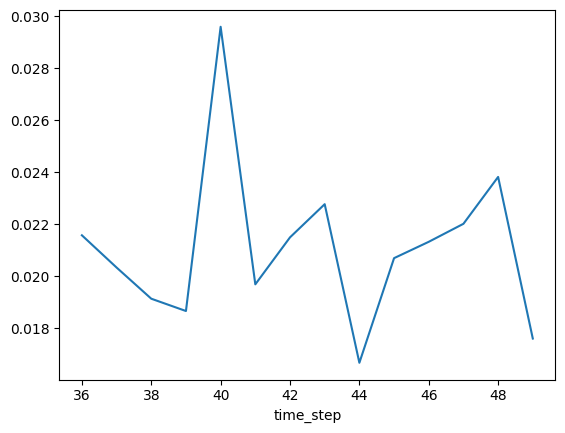

In [55]:
nmf, H, W_test, preds = model_test_orchestrator(X_train_abs, X_test_abs, test_df=test_df, rank=16)


In [56]:
precision, recall = conf_matrix_maker(preds)
precision, recall

tp: 0, fp: 0, tn: 14428, fn: 901


(0, 0.0)

## Test2: MinMax scaler + log

Using a logarithmic transform compresses the range of extreme outliers and handle skewed distributions, which are extremely common in financial data like the Elliptic dataset.
Using the data as is before scaling it, will cause many small transactions to vanish for the Algorithm solver. shrinking the distance between instances helps shift the attention of the solver. 

In Bitcoin transaction data, a "Power Law" distribution exists: most transactions are for small amounts (0.001 BTC), while a tiny few are for massive amounts (1,000 BTC).

log1p = log(1 + x) - handles small negatives better than log(x): 
  1p: shorthand for 1 + x inside the logarithm.

- x = 0 → log(1 + 0) = log(1) = 0 (instead of -inf)
- x = 1 → log(1 + 1) = log(2) ≈ 0.693n (e.g., direction of deviation matters), use QuantileTransformer or MinMaxScaler(clip=True) instead — accepting that extreme OOD values saturate
- x = -0.5 → log(1 + (-0.5)) = log(0.5) ≈ -0.693 (still valid)

> The domain shifts from x > 0 to x > -1.

np.log1p keeps percision around small numbers: For very small x (e.g., x = 1e-10), computing log(1 + x) naively first rounds 1 + x to 1.0 in floating point, then returns log(1.0) = 0.0 — losing all precision. np.log1p uses a special algorithm to compute this accurately without that intermediate rounding error.
Making it standard for count data, probabilities, and small increments.


In [57]:
# Identify feature columns (excluding metadata)
metadata_cols = ['txId', 'time_step', 'class']

sample_size = train_df.shape[0]

train_df_sample = train_df.copy()#.sample(sample_size)
test_df_sample = test_df.copy()#sample(sample_size).copy()
X_train_raw = train_df_sample.drop(columns=metadata_cols)
X_test_raw = test_df_sample.drop(columns=metadata_cols)

In [58]:
train_mins = X_train_raw.min()
X_train_nn = (X_train_raw - train_mins) + 1.0
X_test_nn = (X_test_raw - train_mins) + 1.0
X_train_nn =  np.maximum(X_train_nn, 1e-12) # almost 0 to avoid rounding errors
X_test_nn = np.maximum(X_test_nn, 1e-12)


In [59]:
X_test_nn.loc[(X_test_nn < 0).any(axis=1)]

,lf_1,lf_2,lf_3,lf_4,lf_5,lf_6,lf_7,lf_8,lf_9,lf_10,...,af_68,af_69,af_70,af_71,af_72,in_degree,out_degree,degree_ratio,clustering_coef,pagerank


In [60]:

# Step B: Log Transform 
X_train_log = np.log1p(X_train_nn) 
X_test_log = np.log1p(X_test_nn)


In [61]:

scaler = MinMaxScaler(feature_range=(0,1))
X_train_minmax = scaler.fit_transform(X_train_log)
X_test_minmax = scaler.transform(X_test_log)


In [62]:
(X_test_minmax < 0).any().sum()

np.int64(1)

In [63]:
X_train_minmax = np.maximum(X_train_minmax, 0)
X_test_minmax = np.maximum(X_test_minmax, 0)
(X_test_minmax < 0).any().sum()

np.int64(0)

this is legitimate because: 
In Anomaly Detection, clipping these values is standard practice. If the training set's minimum represents "perfectly normal/quiet," then anything even lower is still effectively "normal/quiet" for the purpose of a reconstruction model trained only on licit data.

In [64]:
#TODO change error calculation

/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


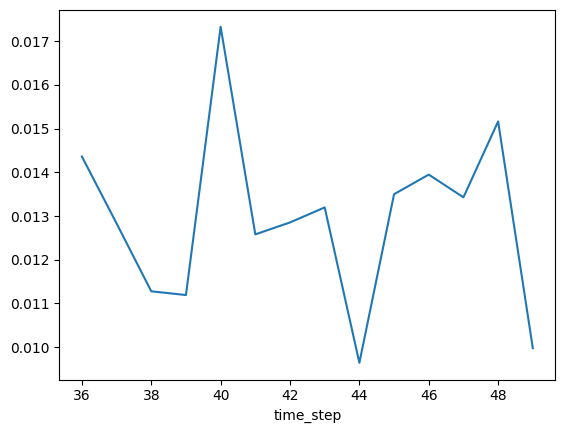

In [65]:
nmf, H, W_test, preds = model_test_orchestrator(X_train_minmax, X_test_minmax, test_df=test_df_sample, rank=16)

In [66]:
precision, recall = conf_matrix_maker(preds)
precision, recall

tp: 6, fp: 1085, tn: 13343, fn: 895


(0.005499541704857928, 0.006659267480577136)

In [67]:
# preds = model_test_orchestrator(X_train, X_test, rank=None)
# precision, recall = conf_matrix_maker(preds)

tp: 77, fp: 4912, tn: 9516, fn: 824
rank 5:
 precision: 0.01543395470034075
 recall: 0.08546059933407325
tp: 17, fp: 2016, tn: 12412, fn: 884
rank 10:
 precision: 0.008362026561731432
 recall: 0.018867924528301886
tp: 0, fp: 339, tn: 14089, fn: 901
rank 30:
 precision: 0.0
 recall: 0.0


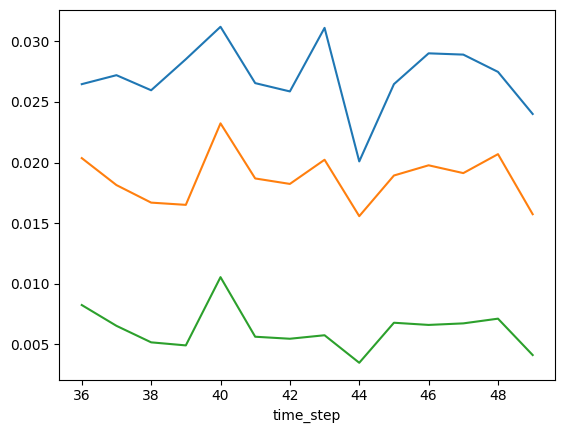

In [68]:
ranks = [ 5, 10, 30]#, 50]#, 100, 165]

results = {}

for k in ranks: 
    nmf, H, W_test, preds_df = model_test_orchestrator(X_train_minmax, X_test_minmax, test_df_sample, rank=k)
    precision, recall = conf_matrix_maker(preds_df)

    results[f'rank_{k}']: {"n_m_f": nmf, 'H_matrix': H, "w_test": W_test, "test_results": preds_df}
    print(f'rank {k}:\n precision: {precision}\n recall: {recall}')

working with these forced scaling of negative values led to even worse results

## Test3: shifting each col by its minimum

In [69]:
min_values = X_train_raw.min()

X_train_min = X_train_raw - min_values
X_test_min = X_test_raw - min_values
(X_test_min < 0).any().sum()

np.int64(17)

In [70]:
X_train_min = np.maximum(X_train_min, 1e-9)
X_test_min = np.maximum(X_test_min, 1e-9)
(X_test_min < 0).any().sum()


np.int64(0)

In [71]:
X_train_min_log = np.log1p(X_train_min) 
X_test_min_log = np.log1p(X_test_min)

scaler = MinMaxScaler(feature_range=(0,1))
X_train_min_scaled = scaler.fit_transform(X_train_min_log)
X_test_min_scaled = scaler.transform(X_test_min_log)


tp: 222, fp: 9405, tn: 5023, fn: 679
rank 5:
 precision: 0.023060143346837023
 recall: 0.24639289678135406
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  0.028441  0.014585  0.003893  0.017687  0.025178  0.036120   
1        901.0  0.015759  0.011234  0.004605  0.007857  0.010956  0.020411   

            max  
class            
0      0.122282  
1      0.066092  
ROC-AUC: 0.2047  |  AP: 0.0341
tp: 169, fp: 7011, tn: 7417, fn: 732
rank 10:
 precision: 0.023537604456824512
 recall: 0.18756936736958935
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  0.020143  0.011137  0.003159  0.012172  0.017558  0.025456   
1        901.0  0.012197  0.007642  0.002782  0.006734  0.009373  0.015691   

            max  
class            
0      0.106104  
1 

/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


tp: 11, fp: 1228, tn: 13200, fn: 890
rank 30:
 precision: 0.00887812752219532
 recall: 0.01220865704772475
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  0.006597  0.006808  0.000182  0.002187  0.004337  0.008552   
1        901.0  0.003152  0.003462  0.000204  0.001163  0.002020  0.003278   

            max  
class            
0      0.076038  
1      0.022841  
ROC-AUC: 0.2977  |  AP: 0.0381


/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


tp: 0, fp: 20, tn: 14408, fn: 901
rank 70:
 precision: 0.0
 recall: 0.0
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  0.000967  0.001620  0.000019  0.000133  0.000438  0.001053   
1        901.0  0.000786  0.001386  0.000020  0.000157  0.000409  0.000693   

            max  
class            
0      0.025403  
1      0.010815  
ROC-AUC: 0.4716  |  AP: 0.0526


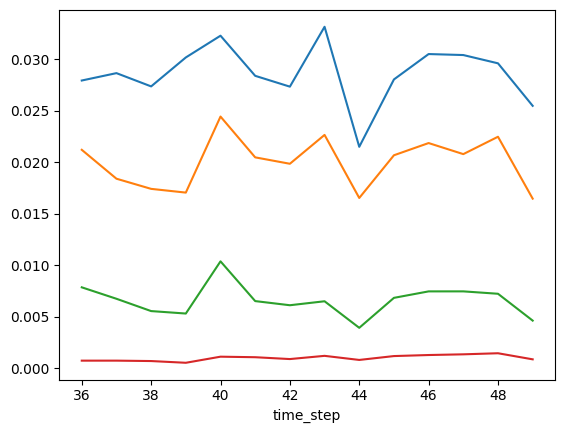

In [72]:
ranks = [ 5, 10, 30, 70]#, 50]#, 100, 165]

results = {}

for k in ranks: 
    nmf, H, W_test, preds_df = model_test_orchestrator(X_train_min_scaled, X_test_min_scaled, test_df, rank=k)
    precision, recall = conf_matrix_maker(preds_df)

    results[f'rank_{k}']: {"n_m_f": nmf, 'H_matrix': H, "w_test": W_test, "test_results": preds_df}
    print(f'rank {k}:\n precision: {precision}\n recall: {recall}')


    labeled = preds_df[preds_df['class'] < 2].copy()                                                              
    
    print(labeled.groupby('class')['anomaly_score'].describe())                                                   
                    
    auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])                                               
    ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
    print(f'ROC-AUC: {auc:.4f}  |  AP: {ap:.4f}') 

## Test4: Yeo-Johnson

In [73]:
X_train_yj_df = train_df.copy()
X_test_yj_df = test_df.copy()

X_train_yj_raw = X_train_yj_df.drop(metadata_cols, axis=1)
X_test_yj_raw = X_test_yj_df.drop(metadata_cols, axis=1)



In [74]:
pt = PowerTransformer(method='yeo-johnson')

X_train_yj = pt.fit_transform(X_train_yj_raw)

shift = X_train_yj.min(axis=0)  # per-column, train only
X_train_nn_yj = X_train_yj - shift

X_test_yj = pt.transform(X_test_yj_raw)
X_test_nn_yj = X_test_yj - shift  # same shift — test may still go slightly negative
X_test_nn_yj = np.clip(X_test_nn_yj, 0, None)  # small clip for safety

In [75]:
(X_test_nn_yj<0).any().sum()

np.int64(0)

/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


tp: 18, fp: 699, tn: 13729, fn: 883
rank 5:
 precision: 0.02510460251046025
 recall: 0.01997780244173141
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  0.712995  0.450984  0.205821  0.504542  0.645388  0.807456   
1        901.0  0.543184  0.346362  0.202406  0.381806  0.469296  0.593307   

             max  
class             
0      11.555345  
1       3.487218  
ROC-AUC: 0.2699  |  AP: 0.0395
tp: 18, fp: 415, tn: 14013, fn: 883
rank 10:
 precision: 0.04157043879907621
 recall: 0.01997780244173141
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  0.501512  0.429147  0.113221  0.328742  0.415063  0.553433   
1        901.0  0.369849  0.335385  0.128919  0.234055  0.297908  0.394552   

             max  
class             
0      11.433123  

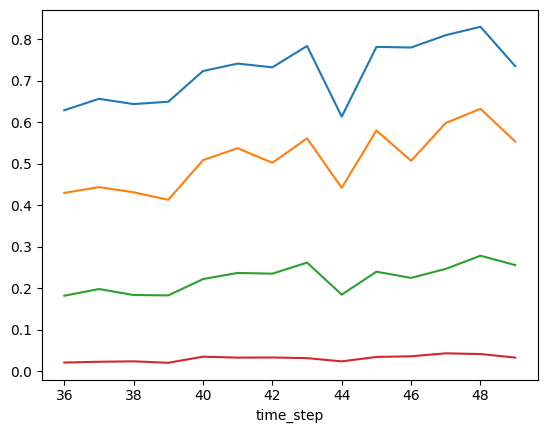

In [76]:
ranks = [ 5, 10, 30,70]#, 50]#, 100, 165]

results = {}

for k in ranks: 
    nmf, H, W_test, preds_df = model_test_orchestrator(X_train_nn_yj, X_test_nn_yj, X_test_yj_df, rank=k)
    precision, recall = conf_matrix_maker(preds_df)

    results[f'rank_{k}']: {"n_m_f": nmf, 'H_matrix': H, "w_test": W_test, "test_results": preds_df}
    print(f'rank {k}:\n precision: {precision}\n recall: {recall}')

    labeled = preds_df[preds_df['class'] < 2].copy()                                                              
    
    print(labeled.groupby('class')['anomaly_score'].describe())                                                   
                    
    auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])                                               
    ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
    print(f'ROC-AUC: {auc:.4f}  |  AP: {ap:.4f}') 

Yeo-Johnson (YJ) handles negatives natively (unlike Box-Cox), but it does not guarantee non-negative output —
  it transforms toward Gaussianity, not toward [0, ∞). So for NMF you'd still need a shift afterward.

  - YJ compresses the tails first → the subsequent shift is smaller and more uniform across columns → NMF
  components are less polluted by outlier-driven offsets

  What YJ actually does to negatives:
  y >= 0:  ((y+1)^λ - 1) / λ
  y <  0:  -((-y+1)^(2-λ) - 1) / (2-λ)
  The two branches are fit jointly to find λ that makes the whole distribution most normal. The output is still
  real-valued, centered around 0.

  Practical concern: fit YJ only on training data, then transform() test. Test values outside the training range
   may push below the training min after transformation — so the min-shift must also be computed on training
  data only (the leakage bug you already found applies here too).

### Different MF approaches that handle negatives more natively: 
ranked by fit:                                                                                       
                                                                                                               
  1. Truncated SVD — most direct drop-in for NMF      
    Factorizes the data matrix into three matrices: U · Σ · Vᵀ, where Σ contains singular values (importance weights) sorted descending. Keeping only the top-k singular values gives the best rank-k approximation of the original matrix. Anomalies reconstruct poorly because they don't align with the dominant directions of variance learned from normal data.

  - No non-negativity constraint, handles negatives natively                
  - Same workflow: fit on licit train set, use reconstruction error on test
  - sklearn.decomposition.TruncatedSVD

  - **Downside**: components aren't parts-based (interpretability is lower than NMF), but for anomaly scoring that doesn't matter
                                                                                                                                                                                         
  2. Robust PCA (RPCA) — theoretically best fit for this task
    Assumes the data matrix is a sum of two components: a low-rank matrix (the "normal" structure shared across most transactions) plus a sparse matrix (the anomalies — few but large deviations). It solves an optimization problem that simultaneously finds both components. The sparse matrix directly identifies anomalous entries rather than inferring them from reconstruction error.

  - Decomposes M = L + S where L is low-rank (normal behavior) and S is sparse (anomalies)
  - The sparse component S directly captures anomalies — no need to compute reconstruction error as a proxy
  - Handles negatives natively                                                                             
  - **Downside:** no sklearn built-in; needs rpca package or manual ADMM implementation; expensive on 200k rows
                                                                                                           
  3. Semi-NMF — stay close to NMF but relax the constraint
  Assumes the data matrix is a sum of two components: a low-rank matrix (the "normal" structure shared across most transactions) plus a sparse matrix (the anomalies — few but large deviations). It solves an optimization problem that simultaneously finds both components. The sparse matrix directly identifies anomalous entries rather than inferring them from reconstruction error.
  
  - Allows the data matrix and one factor to have negatives; only one factor is non-negative
  - Preserves the parts-based decomposition intuition of NMF
  - **Downside:** No sklearn support — needs manual implementation or nimfa library  

# Testing different algorithms

## 1. Truncated SVD

In [81]:
### helper function
def TSVD_executor(X_train, X_test, test_df, rank=16,  algorithm = 'randomized'):
    
    svd = TruncatedSVD(n_components=rank, algorithm=algorithm)
    svd.fit(X_train)
    X_test_transformed = svd.transform(X_test)
    X_test_recon = svd.inverse_transform(X_test_transformed)

    # measure the error
    errors = np.mean((X_test - X_test_recon)**2, axis=1)
    
    test_results = pd.DataFrame({
        'txId': test_df['txId'].values,
        'time_step': test_df['time_step'].values,
        'class': test_df['class'].values,
        'anomaly_score': errors
    })
    
    # normalize error: 
    test_results['norm_error'] = StandardScaler().fit_transform(test_results[['anomaly_score']]).flatten()
    test_results[test_results['class'] == 0].groupby('time_step')['anomaly_score'].mean().plot()

    return svd, X_test_recon, test_results



In [82]:
sample_size = 1000
train_tsvd_df = train_df.copy() #.sample(sample_size).copy()
test_tsvd_df = test_df.copy()  # .sample(sample_size).copy()

train_tsvd_df_raw = train_tsvd_df.drop(metadata_cols, axis=1)
test_tsvd_df_raw = test_tsvd_df.drop(metadata_cols, axis=1)


In [83]:
# scaling
st_scaler = StandardScaler()
X_train_tsvd = st_scaler.fit_transform(train_tsvd_df_raw)
X_test_tsvd = st_scaler.transform(test_tsvd_df_raw)


tp: 0, fp: 0, tn: 14428, fn: 901
rank 5:
 precision: 0
 recall: 0.0
         count      mean       std       min       25%      50%       75%  \
class                                                                       
0      14428.0  1.405150  3.965125  0.090608  0.330102  0.48854  0.874908   
1        901.0  0.714696  3.804021  0.112073  0.208106  0.30480  0.458954   

              max  
class              
0      130.088431  
1      106.125837  
ROC-AUC: 0.2721  |  AP: 0.0374
tp: 0, fp: 0, tn: 14428, fn: 901
rank 30:
 precision: 0
 recall: 0.0
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  0.595883  2.152163  0.020352  0.091577  0.163313  0.365626   
1        901.0  0.340147  2.624131  0.014083  0.052657  0.080338  0.132967   

             max  
class             
0      89.759134  
1      75.672881  
ROC-AUC: 0.2797  |  AP: 0.0386
tp: 1, fp: 3, tn: 14425

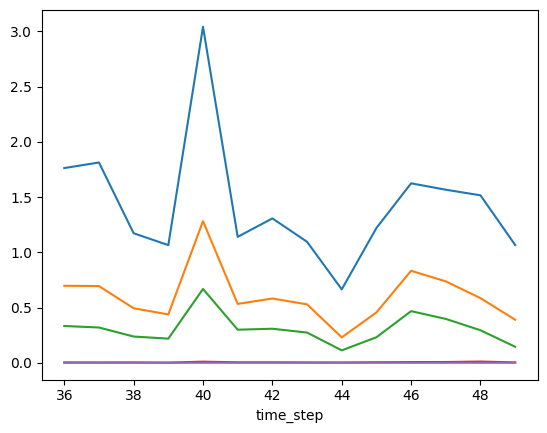

In [84]:
for rank in [5, 30, 50, 100, 160]:
    tsvd, X_test_recon, test_results = TSVD_executor(
        X_train_tsvd, 
        X_test_tsvd,
        test_tsvd_df,
        rank=rank                                         
    )

    precision, recall = conf_matrix_maker(test_results, th=0.1)
    print(f'rank {rank}:\n precision: {precision}\n recall: {recall}')

    labeled = test_results[test_results['class'] < 2].copy()                                                              
    
    print(labeled.groupby('class')['anomaly_score'].describe())                                                   
                    
    auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])                                               
    ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
    print(f'ROC-AUC: {auc:.4f}  |  AP: {ap:.4f}') 

In [26]:
test_df[test_df['class'] < 2].groupby('class')['node_degree'].describe()                  


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
0,14428.0,3.317923,8.962181,1.0,1.0,2.0,2.0,241.0
1,901.0,2.022198,7.133299,1.0,1.0,1.0,2.0,177.0


there is no visible separation in the graph feature between classes 0 and 1

In [86]:
for col in ['in_degree', 'out_degree', 'degree_ratio', 'clustering_coef', 'pagerank']:
      print(col)
      print(test_df[test_df['class'] < 2].groupby('class')[col].describe())                 
      print() 

in_degree
         count      mean       std  min  25%  50%  75%    max
class                                                        
0      14428.0  2.060507  8.728319  0.0  0.0  1.0  1.0  241.0
1        901.0  1.332963  7.175430  0.0  0.0  1.0  1.0  177.0

out_degree
         count      mean       std  min  25%  50%  75%   max
class                                                       
0      14428.0  1.257416  1.829193  0.0  1.0  1.0  1.0  99.0
1        901.0  0.689234  0.631564  0.0  0.0  1.0  1.0   3.0

degree_ratio
         count          mean           std  min  25%  50%           75%  \
class                                                                     
0      14428.0  7.705850e+08  5.826770e+09  0.0  0.0  1.0  4.000000e+00   
1        901.0  9.789123e+08  7.193562e+09  0.0  0.0  1.0  1.000000e+09   

                max  
class                
0      2.410000e+11  
1      1.770000e+11  

clustering_coef
         count      mean       std  min  25%  50%  75%  max
class 

## Semi-NMF

Probelm with loss and updating W: the loss stays the same after the first iteration.
```python
losses = [] 
    for _ in range(n_iter):                                                               
        W = update_W_semi(H, V)                                                           
        H = np.maximum(update_H_semi(W, H, V), 1e-10)
        losses.append(np.linalg.norm(V - W @ H, 'fro') ** 2) 
```
conclusion: 
After iteration 1, W is solved exactly via least squares (optimal for the current H). This over-constrains the H update — the multiplicative step with sqrt is very conservative and barely moves H, so W has nothing new to optimize for. The algorithm stalls.
Alternatives
1. Drop the sqrt (plain multiplicative)                                                   
  H = H * (num / den)  # instead of sqrt(num/den)
    More aggressive steps, same convergence guarantee doesn't hold but often works better in practice. Try this first — simplest change. 
2. Projected gradient descent (PGD)                                                                     
    More direct, no sqrt dampening. Requires tuning lr. 
3. HALS (Hierarchical Alternating Least Squares)                                          
  Updates H one row at a time — generally the fastest converging option for NMF-type problems, what modern implementations use.
4. use GD for updating W
  

releases the non negative constraints, on expense of explainability 

In [138]:
def _pos(A): return np.maximum(A, 0)
def _neg(A): return np.maximum(-A, 0)
                                                                                            
def update_H_semi(W, H, V):
    """H: (k X m), W: (n Xk), V: (n X m) — multiplicative update, keeps H ≥ 0"""               
    WtV = W.T @ V           # (k×m)                                                       
    WtW = W.T @ W           # (k×k)                                                       
    num = _pos(WtV) + _neg(WtW) @ H                                                       
    den = _neg(WtV) + _pos(WtW) @ H + 1e-10                                               
    return H * num / den #np.sqrt(num / den)  

def update_H_pgd(W, H, V, lr=0.01):                                                       
    grad = W.T @ W @ H - W.T @ V   # ∇_H of ||V - WH||²
    return np.maximum(H - lr * grad, 0)  # gradient step + project to ≥ 0  

def update_H_hals(W, H, V):
      WtW = W.T @ W   # (k×k)                                                               
      WtV = W.T @ V   # (k×m)
      for r in range(H.shape[0]):                                                           
          H[r] = np.maximum(     
              (WtV[r] - WtW[r] @ H + WtW[r, r] * H[r]) / (WtW[r, r] + 1e-10), 0)                                                                                 
      return H                                                         

def update_W_semi(H, V):                                                                  
    """W update: unconstrained least squares — W = V Hᵀ (H Hᵀ)⁻¹"""
    return np.linalg.lstsq(H @ H.T, (V @ H.T).T, rcond=None)[0].T                         

def update_W_gd(W, H, V, lr=None):
      grad = (W @ H - V) @ H.T   # (n×k)                                                    
      if lr is None:
          lr = 1.0 / (np.linalg.norm(H @ H.T, 2) + 1e-10)  # Lipschitz step
      return W - lr * grad
                                                                                            
def run_semi_nmf(V, rank=16, n_iter=100, random_state=90):
    rng = np.random.default_rng(random_state)                                             
    n, m = V.shape   

# initialize from SVD — W aligned with data variance, H non-negative                  
    svd = TruncatedSVD(n_components=rank, random_state=90)
    W = svd.fit_transform(V)          # (n × rank): projection scores                     
    H = np.maximum(svd.components_, 0) # (rank × m): clip components to ≥ 0                                                                      
    # H = np.abs(rng.standard_normal((rank, m)))   # H ≥ 0
    # W = rng.standard_normal((n, rank))            # W unconstrained                       
    losses = [] 
    for _ in range(n_iter):                                                               
        W = update_W_gd(W, H, V)                                                           
        H = np.maximum(update_H_hals(W, H, V), 1e-10)
        loss = np.linalg.norm(V - W @ H, 'fro') ** 2
        losses.append(loss)
                                    
    return W, H, losses                                                                   
  
def semi_nmf_orchestrator(X_train, X_test, test_df, rank=16, n_iter=100):
    X_train = np.array(X_train.copy())                                                           
    X_test  = np.array(X_test.copy())
                 
    W_train, H, losses = run_semi_nmf(X_train, rank=rank, n_iter=n_iter)
                                                             
    # transform: fix H, solve W_test via least squares (no iteration needed)              
    W_test = np.linalg.lstsq(H @ H.T, (X_test @ H.T).T, rcond=None)[0].T                  
                                                                                        
    X_test_recon = W_test @ H
    errors = np.mean((X_test - X_test_recon) ** 2, axis=1)                                
                
    test_results = pd.DataFrame({                                                         
        'txId':        test_df['txId'].values,
        'time_step':   test_df['time_step'].values,                                       
        'class':       test_df['class'].values,                                           
        'anomaly_score': errors
    })                                                                                    
    scaler = MinMaxScaler()
    test_results['norm_error'] = scaler.fit_transform(errors.reshape(-1, 1)).flatten()    
    labeled = test_results[test_results['class'] < 2]
    labeled.boxplot(column='anomaly_score', by='class')                                       
   
               
    return W_train, H, W_test, test_results, losses  

In [ ]:
W_train, H, W_test, test_results, losses = semi_nmf_orchestrator(X_train_raw, X_test_raw, test_df, rank=40)

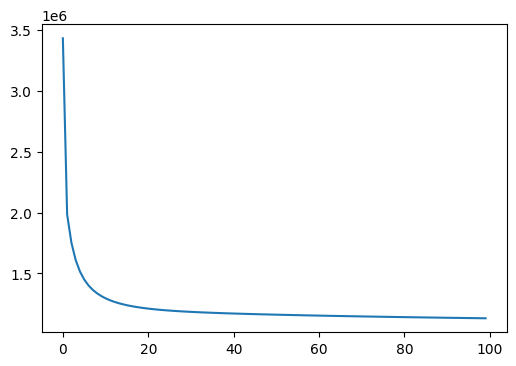

In [134]:
fig, ax = plt.subplots(figsize= [6,4])
ax.plot(losses)
plt.show()

tp: 2, fp: 117, tn: 14311, fn: 899
rank 5: 
 precision: 0.01680672268907563
 recall: 0.0022197558268590455
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  1.730854  7.928986  0.086439  0.362175  0.627110  1.266255   
1        901.0  0.598320  2.563496  0.074331  0.148322  0.252688  0.502140   

              max  
class              
0      318.343541  
1       57.234048  
ROC-AUC: 0.2219  |  AP: 0.0349
tp: 2, fp: 68, tn: 14360, fn: 899
rank 10: 
 precision: 0.02857142857142857
 recall: 0.0022197558268590455
         count      mean       std       min       25%       50%       75%  \
class                                                                        
0      14428.0  1.362814  6.547743  0.079981  0.342182  0.578807  1.079015   
1        901.0  0.549045  2.032692  0.068970  0.139165  0.239549  0.481185   

              max  
class              
0      30

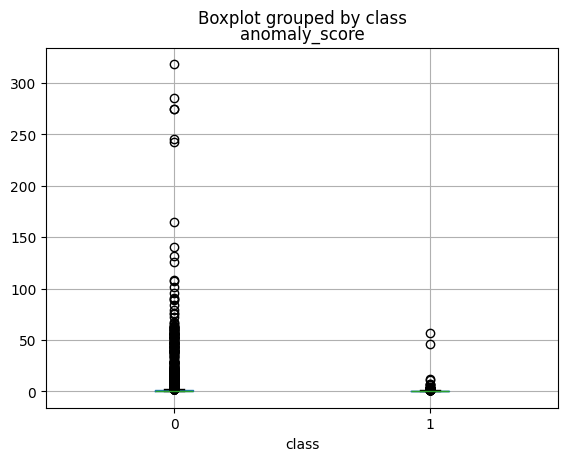

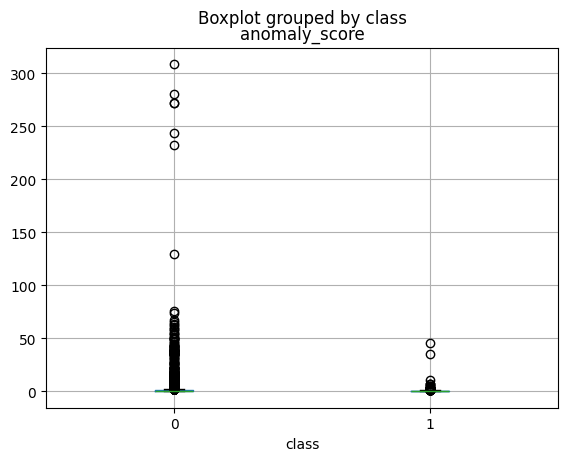

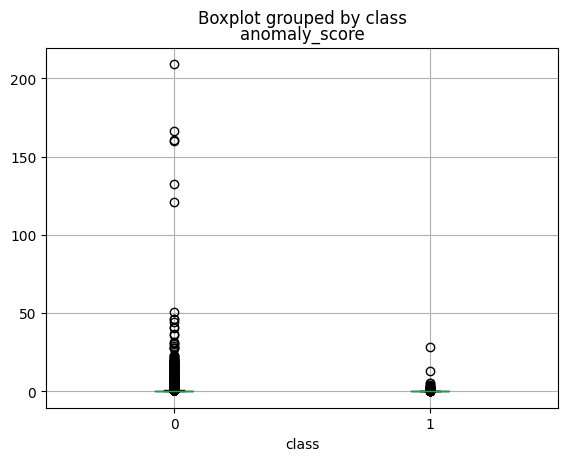

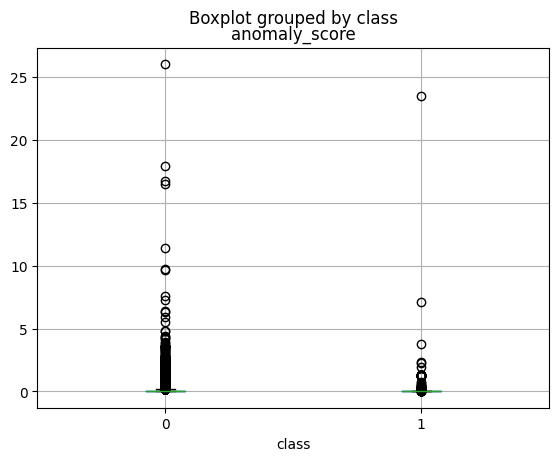

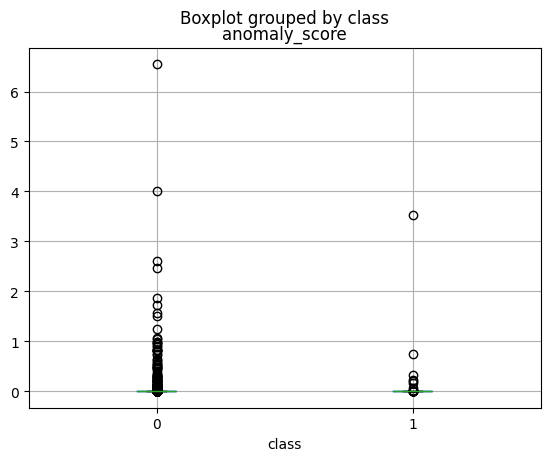

In [140]:
ranks = [ 5, 10, 30,70, 150]#, 50]#, 100, 165]

for rank in ranks: 
    W_train, H, W_test, test_results, losses = semi_nmf_orchestrator(X_train_raw, X_test_raw, test_df, rank=rank)

    precision, recall = conf_matrix_maker(test_results, th=0.1)
    print(f'rank {rank}: \n precision: {precision}\n recall: {recall}')

    labeled = test_results[test_results['class'] < 2].copy()                                                              

    print(labeled.groupby('class')['anomaly_score'].describe())                                                   
                    
    auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])                                               
    ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
    print(f'ROC-AUC: {auc:.4f}  |  AP: {ap:.4f}') 


 Reconstruction-based CF works when anomalies are genuinely out-of-subspace — they lie in  
  directions the model never saw during training. That assumption requires:
  1. Normal data has consistent low-rank structure                                          
  2. Anomalies deviate from that structure in feature space
                                                           
  For Elliptic, both assumptions are weakly satisfied:
  - Illicit transactions deliberately mimic licit behavior (obfuscation)                    
  - The 165 features are anonymized, compressing the signal                                 
  - Heterogeneous graph means local structure doesn't propagate cleanly                     
                                                                                            
  TSVD is theoretically the best possible linear reconstruction method. Semi-NMF adds       
  interpretability but can't exceed TSVD's separating power on the same features. If TSVD   
  gives 0.54, Semi-NMF won't give 0.7.                                                      
                                                                                            
  The principled conclusion would be: CF via reconstruction error has a ceiling on this     
  dataset because the anomaly signal is in the graph topology, not in individual node
  feature reconstruction error. The model learns what licit transactions look like, but     
  illicit transactions look similar enough in feature space that reconstruction error
  doesn't discriminate.

## 3. Temporal Reconstruction with CF

testing the effect of treating the data as time-series, predicting only one time period into the fucture, and adding it to future training. 
This assumes autoregressiveness, which should not exist in the data, except in the evolution of fraud behavior

In [ ]:
def temporal_semi_nmf(df, metadata_cols, rank=16, n_iter=100):                            
      all_results = []                                                                      
                                                                                            
      timesteps = sorted(df['time_step'].unique())                                          
   
      for ts in timesteps[5:]:                                                                   
          train = df[(df['class'] == 0) & (df['time_step'] < ts)]
          test  = df[df['time_step'] == ts]                                                  
   
          if len(train) < rank * 2:   # not enough data to fit rank components              
              continue
                                                                                            
          X_train = train.drop(columns=metadata_cols)                            
          X_test  = test.drop(columns=metadata_cols)
                                                                                            
          scaler = StandardScaler()                                                         
          X_train_s = scaler.fit_transform(X_train)
          X_test_s  = scaler.transform(X_test)                                              
                  
          W_train, H, _ = run_semi_nmf(X_train_s, rank=rank, n_iter=n_iter)                 
   
          W_test  = np.linalg.solve(H @ H.T, H @ X_test_s.T).T                              
          X_recon = W_test @ H
          errors  = np.mean((X_test_s - X_recon) ** 2, axis=1)                              
                                                                                            
          all_results.append(pd.DataFrame({
              'txId':          test['txId'].values,                                         
              'time_step':     ts,                                                           
              'class':         test['class'].values,
              'anomaly_score': errors                                                       
          }))     

      return pd.concat(all_results, ignore_index=True)                                      


In [149]:
   
  # evaluate                                                                                
all_results = temporal_semi_nmf(enriched_df, metadata_cols=['txId', 'time_step', 'class'])


In [150]:
labeled = all_results[all_results['class'] < 2]
print(roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score']))  

0.242383382778873


In [ ]:
def plot_temporal_errors(all_results):
    labeled = all_results[all_results['class'] < 2]

    # mean + std per class per timestep
    stats = labeled.groupby(['time_step', 'class'])['anomaly_score'].agg(['mean', 'std']).reset_index()
  
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
                
    colors = {0: 'steelblue', 1: 'crimson'}
    labels = {0: 'Licit', 1: 'Illicit'}

    # top: mean error per class with std band
    for cls in [0, 1]:
        d = stats[stats['class'] == cls]
        ax1.plot(d['time_step'], d['mean'], color=colors[cls], label=labels[cls])
        ax1.fill_between(d['time_step'],
                        d['mean'] - d['std'],
                        d['mean'] + d['std'],
                        alpha=0.2, color=colors[cls])
    ax1.set_ylabel('Mean reconstruction error')
    ax1.legend()
    ax1.axvline(x=35, color='gray', linestyle='--', alpha=0.5, label='train cutoff')

    # bottom: gap (illicit - licit) — positive = model detects fraud
    licit   = stats[stats['class'] == 0].set_index('time_step')['mean']
    illicit = stats[stats['class'] == 1].set_index('time_step')['mean']
    gap = illicit - licit
    ax2.bar(gap.index, gap.values, color=gap.apply(lambda x: 'crimson' if x > 0 else 'steelblue'))
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Error gap (illicit − licit)')
    ax2.set_xlabel('Time step')

    plt.tight_layout()
    plt.show()


In [151]:
all_results[all_results['class'] < 2].groupby(['time_step', 'class']).size()


time_step  class
6          0         480
           1           5
7          0        1101
           1         102
8          0        1098
                    ... 
47         1          22
48         0         435
           1          36
49         0         420
           1          56
Length: 88, dtype: int64

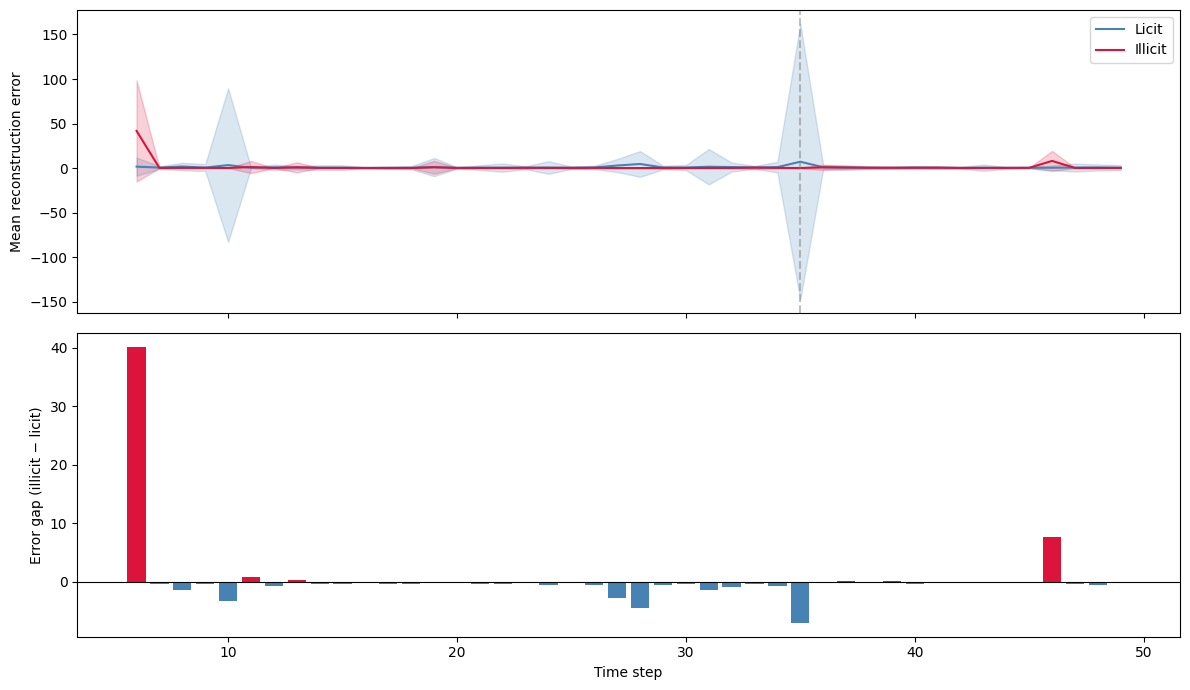

In [152]:
plot_temporal_errors(all_results)

Clear picture — confirms H0 for temporal NMF too:                                         
                                                                                            
  - Both lines are essentially flat at 0 with overlapping means throughout — no consistent separation
  - The large licit std bands at t≈5 and t≈35 are artifacts: t≈5 has tiny training data (high variance), t≈35 is the train cutoff boundary
  - The gap plot is mostly blue (negative) — licit reconstructs worse than fraud in most timesteps, same pattern as the static model
  - The two positive bars (t≈5, t≈47) are noise, not signal
                                            
                  
Conclusion: linear reconstruction-based CF (static or temporal) has been exhausted. The ceiling is ~0.51 AUC on this feature set. Time to move to autoencoders — same philosophy,
  non-linear manifold, same temporal extension available if needed. 